In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('ecommerce_sales_analytics_5000.csv')

In [4]:
df.shape

(5000, 12)

In [5]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB


In [7]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [8]:
df.head(5)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [34]:
## Creating a new column 'total_sales' to calculate the total sales amount for each transaction.
# total_sales = df['quantity'] * df['unit_price'] and also apply the discount from the 'discount' column to get the final sales amount.

df['total_sales'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])

In [35]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,total_sales
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,1883.1960
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,304.1038
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,644.3496
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2569.9030
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,468.5645


In [10]:
# Printing the unique values of these columns: product_category, region, and payment_method to understand the diversity of the data.
print("Unique product categories:", df['product_category'].unique())
print("\nUnique regions:", df['region'].unique())
print("\nUnique payment methods:", df['payment_method'].unique())

Unique product categories: <StringArray>
['Beauty', 'Clothing', 'Electronics', 'Home']
Length: 4, dtype: str

Unique regions: <StringArray>
['South', 'East', 'West', 'North']
Length: 4, dtype: str

Unique payment methods: <StringArray>
['Wallet', 'Card', 'COD']
Length: 3, dtype: str


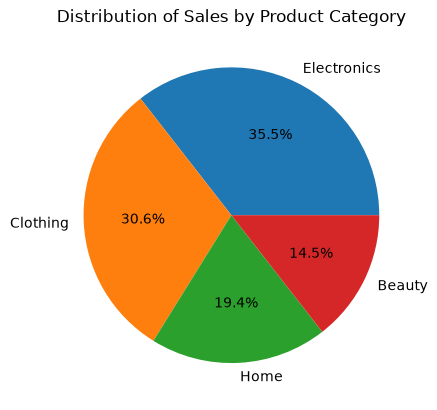

In [ ]:
## Plotting the pie chart for product categories to visualize the distribution of sales across different product categories.

product_category_counts = df['product_category'].value_counts()
product_category_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Sales by Product Category')
plt.ylabel('')
plt.show()

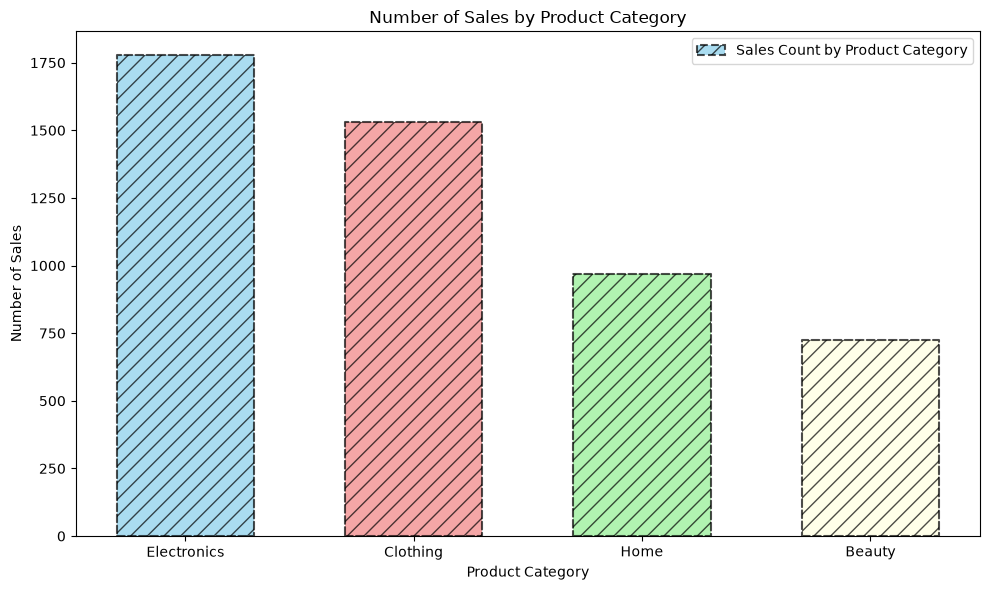

In [16]:
## Bar Graph for product categories

plt.figure(figsize=(10, 6))
plt.bar(product_category_counts.index, product_category_counts.values, color=['skyblue', 'lightcoral', 'lightgreen', 'lightyellow', 'lightpink'], edgecolor='black', alpha=0.7, width=0.6, align='center', linewidth=1.5, zorder=3, linestyle='--', hatch='//', capstyle='round', joinstyle='round', antialiased=True, fill=True, label='Sales Count by Product Category', error_kw={'elinewidth': 2, 'ecolor': 'red'})
plt.title('Number of Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Sales')
# plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

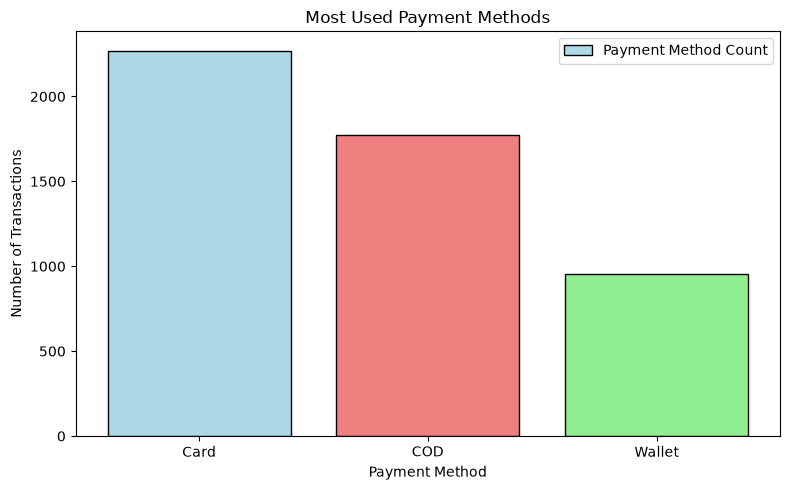

In [19]:
## Visualizing most used payment_method

payment_method_counts = df['payment_method'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(payment_method_counts.index, payment_method_counts.values, color=['lightblue', 'lightcoral', 'lightgreen'], edgecolor='black')
plt.title('Most Used Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
# plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(["Payment Method Count"])
plt.show()

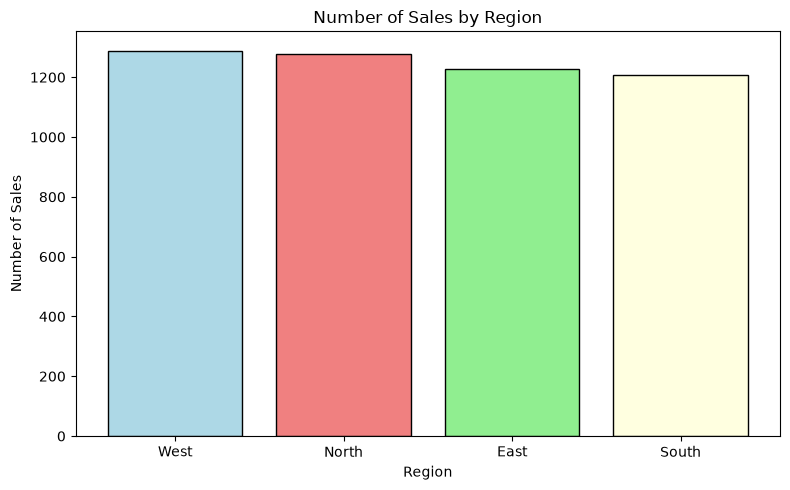

In [20]:
## Visualizing the number of sales by region

region_counts = df['region'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(region_counts.index, region_counts.values, color=['lightblue', 'lightcoral', 'lightgreen', 'lightyellow'], edgecolor='black')
plt.title('Number of Sales by Region')
plt.xlabel('Region')
plt.ylabel('Number of Sales')
plt.tight_layout()
plt.show()

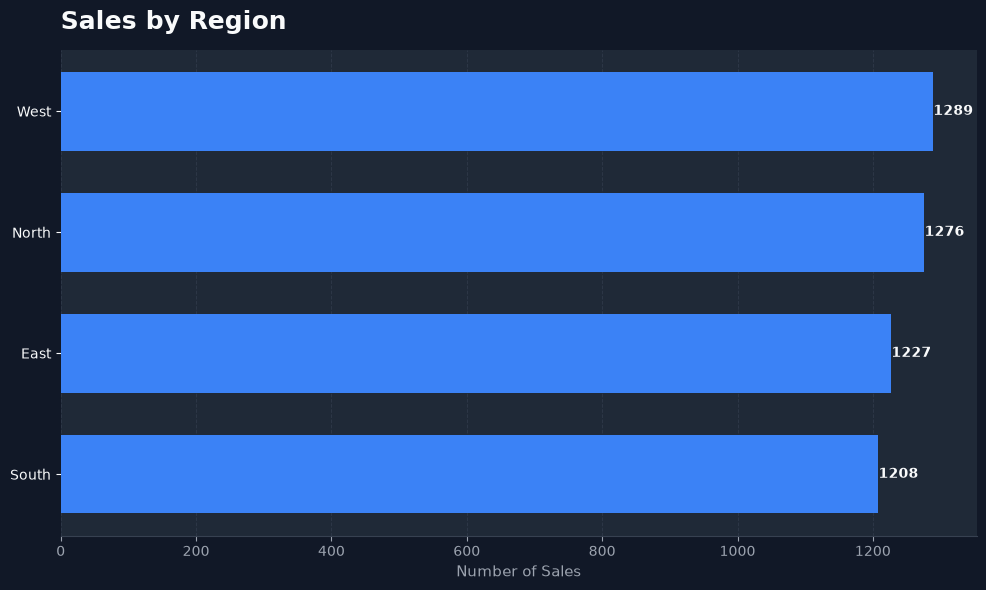

In [24]:
# Count sales by region
region_counts = df["region"].value_counts().sort_values(ascending=False)

# Professional dark theme
bg = "#111827"        # Background
panel = "#1F2937"     # Plot area
bar = "#3B82F6"       # Professional blue
text = "#F9FAFB"
muted = "#9CA3AF"
grid = "#374151"

fig, ax = plt.subplots(figsize=(10, 6), facecolor=bg)
ax.set_facecolor(panel)

# Horizontal bar chart
bars = ax.barh(
    region_counts.index,
    region_counts.values,
    color=bar,
    edgecolor="none",
    height=0.65
)

# Highest value on top
ax.invert_yaxis()

# Value labels
for bar_obj in bars:
    width = bar_obj.get_width()
    ax.text(
        width + 0.3,
        bar_obj.get_y() + bar_obj.get_height()/2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=10,
        color=text,
        fontweight="semibold"
    )

# Clean grid
ax.xaxis.grid(True, linestyle="--", linewidth=0.7, color=grid, alpha=0.6)
ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(grid)

# Titles
ax.set_title(
    "Sales by Region",
    fontsize=18,
    fontweight="bold",
    color=text,
    loc="left",
    pad=15
)

ax.set_xlabel("Number of Sales", color=muted, fontsize=11)
ax.set_ylabel("")

# Tick styling
ax.tick_params(axis="x", colors=muted)
ax.tick_params(axis="y", colors=text)

plt.tight_layout()
plt.show()

In [26]:
df.head(5)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [38]:
## Picking up Top 10 Customers by total_sales

top_customers = df.groupby('customer_id')['total_sales'].sum().sort_values(ascending=False).head(10)
top_customers

customer_id
1663    17680.7023
1955    16265.1461
1675    15036.4703
1276    15023.7085
1647    14894.9657
1804    14330.9726
1193    14151.6539
1836    14110.7934
1957    13956.9363
1735    13146.2592
Name: total_sales, dtype: float64

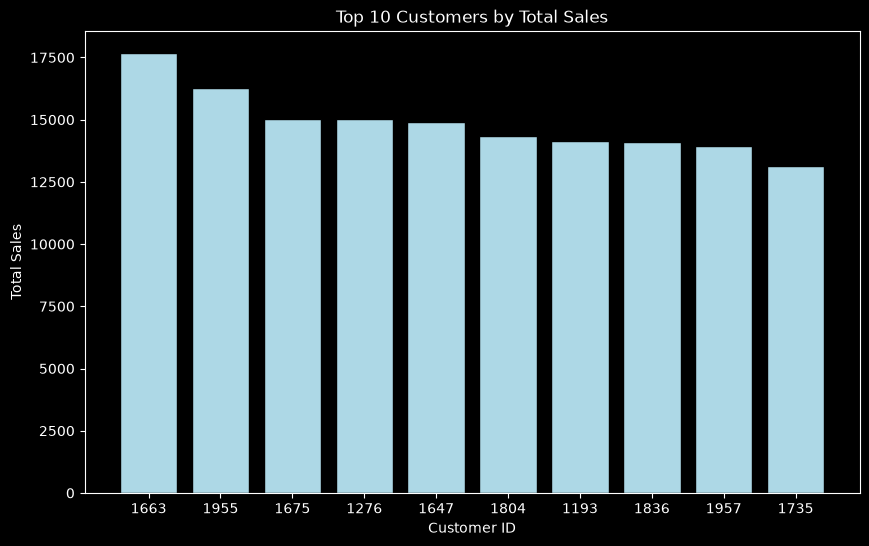

In [39]:
## plotting the top 10 customers by total sales
plt.figure(figsize=(10, 6))
plt.bar(top_customers.index.astype(str), top_customers.values, color='lightblue', edgecolor='black')
plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')
plt.show()

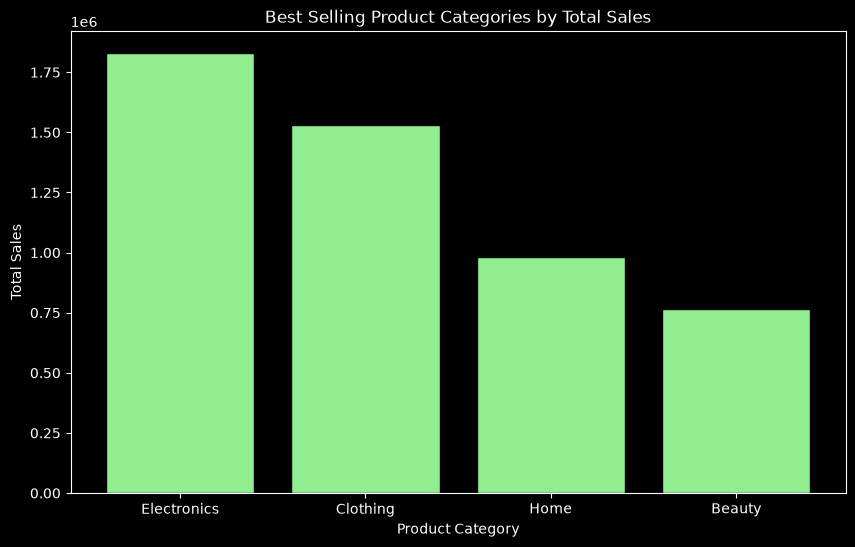

In [41]:
## Best Selling product_category by total_sales
plt.figure(figsize=(10, 6))
plt.bar(df.groupby('product_category')['total_sales'].sum().sort_values(ascending=False).index, df.groupby('product_category')['total_sales'].sum().sort_values(ascending=False).values, color='lightgreen', edgecolor='black')
plt.title('Best Selling Product Categories by Total Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.show()